<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

Anote su hipótesis y compruébela después de ejecutar el notebook.


### Mi hipótesis

`CHANNEL = 0` representa el **primer canal disponible del registro**. En Python el conteo empieza en 0, así que `CHANNEL = 1` sería el segundo canal.

In [ ]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 48.7 MB/s eta 0:00:00


In [ ]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [ ]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [ ]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [ ]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?
2. ¿Cuántos canales tiene?
3. ¿Cómo se llama el canal seleccionado?
4. ¿Cuál es la duración total del registro?
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?


### Respuestas — análisis 1

1. La frecuencia de muestreo del registro 100 es **360 Hz**.
2. Tiene **2 canales**.
3. Con `CHANNEL = 0`, el canal seleccionado es **MLII**.
4. La duración total es:

   \[
   \frac{650000}{360}=1805.56\ s
   \]

   que equivale aproximadamente a **30 min 5.56 s**.
5. Si `fs = 360 Hz`, en 1 segundo se adquieren **360 muestras**.
6. En 10 segundos se adquieren:

   \[
   360\times10=3600\text{ muestras}
   \]


## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [ ]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [ ]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [ ]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


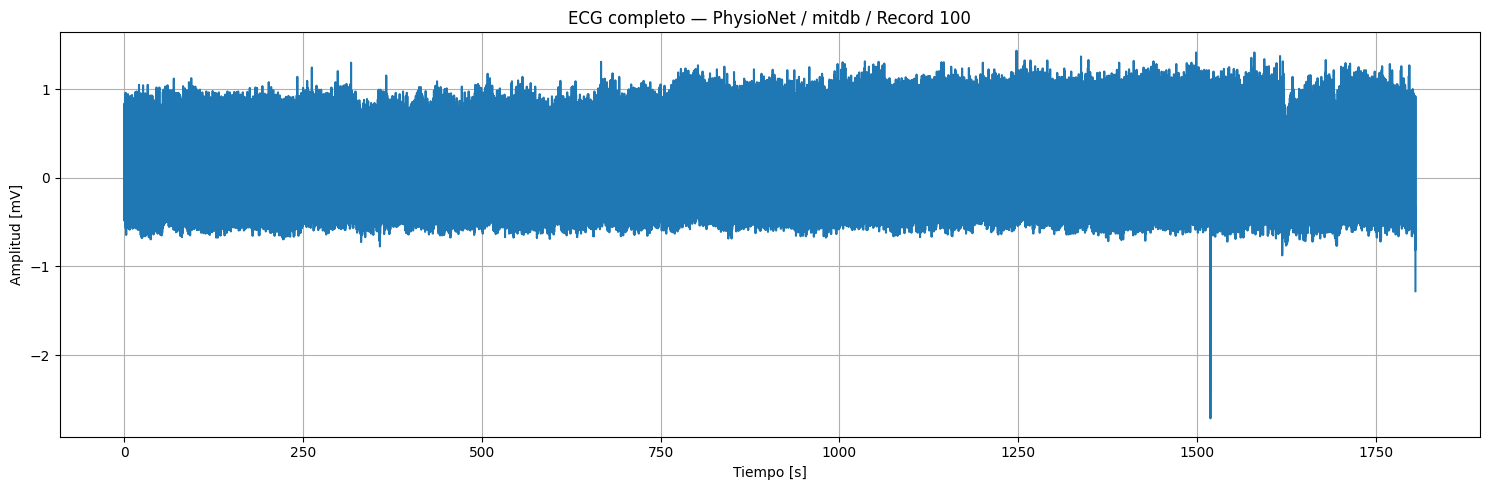

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
2. ¿Se pueden identificar visualmente complejos QRS?
3. ¿La morfología permanece igual durante todo el registro?
4. ¿Se observa ruido?
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?


### Respuestas — análisis 2

1. **No.** La amplitud cambia a lo largo del registro porque el ECG tiene ondas y complejos con diferentes amplitudes.
2. **Sí**, aunque en la gráfica completa están muy juntos. Se distinguen mucho mejor cuando se observa un segmento corto.
3. **No permanece exactamente igual.** Los latidos tienen una forma parecida, pero hay variaciones entre ellos.
4. Se observan pequeñas variaciones de la línea de base y del trazado que pueden corresponder a ruido o artefactos.
5. Ver varios minutos permite observar cambios que no aparecerían en un segmento corto, por ejemplo variaciones del ritmo o eventos aislados.
6. Si la gráfica es demasiado extensa, los complejos QRS quedan comprimidos y es difícil analizar la forma de cada latido.


# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [ ]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


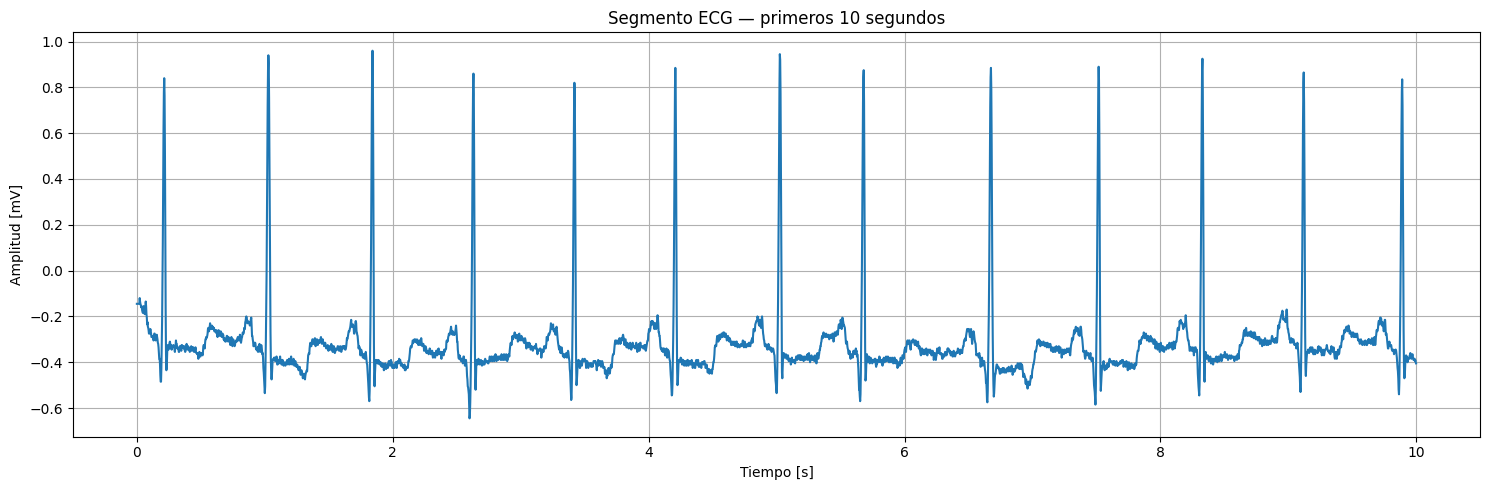

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


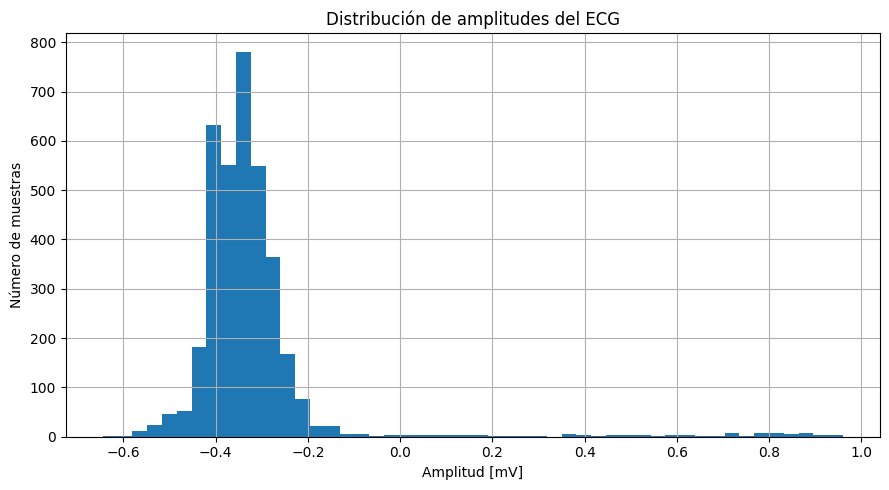

In [ ]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?
2. ¿La distribución parece simétrica?
3. ¿Existen valores extremos?
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
5. ¿El histograma conserva información temporal? Explique.


### Respuestas — análisis 3

1. La mayor cantidad de muestras se concentra cerca de los valores de amplitud que forman la **línea de base y las partes más prolongadas del ciclo cardíaco**.
2. La distribución **no es completamente simétrica**.
3. Sí aparecen valores más alejados del centro, principalmente por los picos de mayor amplitud del ECG.
4. Los valores muy diferentes al valor central pueden aparecer durante los complejos QRS y también por ruido o artefactos.
5. **No.** El histograma cuenta cuántas veces aparece cada rango de amplitud, pero no indica en qué instante apareció cada muestra.


# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


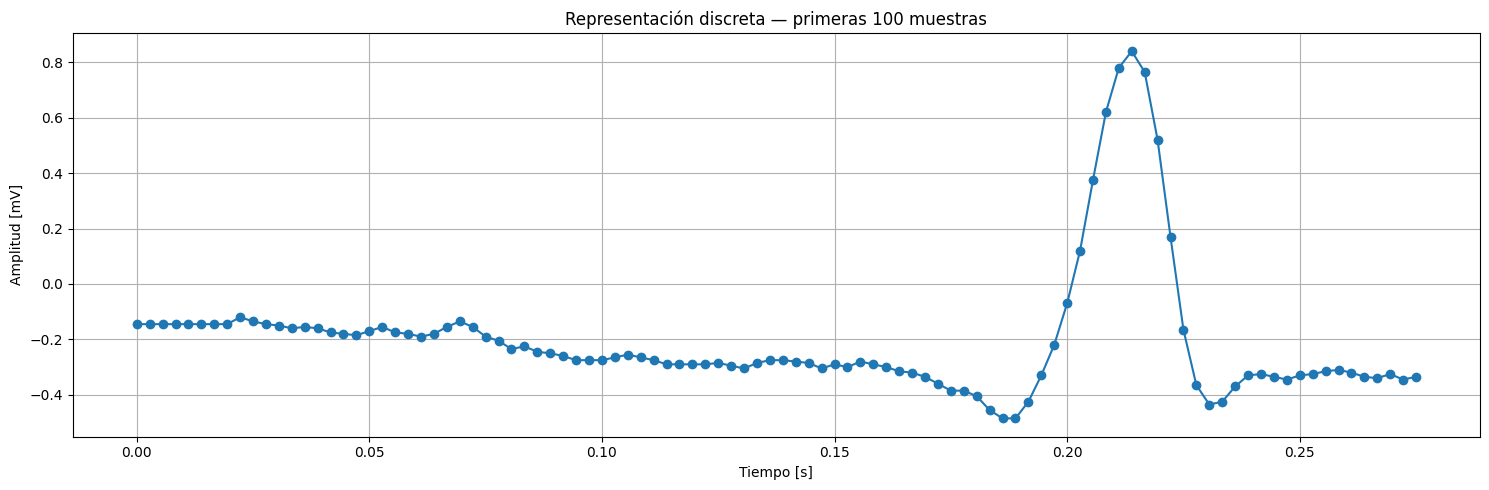

In [ ]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?
2. ¿Qué ocurre si aumentamos `fs`?
3. ¿Qué ocurre si disminuimos `fs`?
4. ¿Qué representa el eje `n` en una señal discreta?
5. ¿Cuál es la relación entre `n`, `fs` y `t`?


### Respuestas — análisis 4

1. Existen **360 muestras por segundo**.
2. Si aumenta `fs`, se toman más muestras por segundo y la señal queda representada con mayor resolución temporal.
3. Si disminuye `fs`, se toman menos muestras y se puede perder detalle de cambios rápidos de la señal.
4. El eje `n` representa el **índice de cada muestra**.
5. La relación es:

   \[
   t[n]=\frac{n}{f_s}
   \]

   Por ejemplo, con `fs = 360 Hz`, entre dos muestras consecutivas pasan aproximadamente **2.78 ms**.


# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [ ]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050


### Interpretación de las estadísticas

- **Media:** indica alrededor de qué valor se encuentra centrado el segmento.
- **Desviación estándar:** indica cuánto se alejan las amplitudes respecto a la media.
- **Máximo:** es la mayor amplitud encontrada en los 10 segundos.
- **Mínimo:** es la menor amplitud del segmento.
- **Rango:** es la diferencia entre el máximo y el mínimo, por lo que muestra qué tan amplio fue el cambio total de amplitud.


# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [ ]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [ ]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [ ]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?
2. ¿El sonido corresponde a un sonido fisiológico real?
3. ¿Por qué un ECG puede convertirse a WAV?
4. ¿Qué información se conserva al hacer la conversión?
5. ¿Qué información fisiológica podría perderse al escucharla?
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?


### Respuestas — análisis 5

1. Sí se puede percibir una señal rítmica, aunque no suena como un latido cardíaco real.
2. **No.** El ECG registra actividad eléctrica, no una señal acústica.
3. Puede convertirse a WAV porque ambos formatos pueden representar una secuencia de muestras ordenadas en el tiempo.
4. Se conserva el orden de las muestras y la separación temporal definida por la frecuencia de muestreo.
5. Al escucharlo es difícil reconocer directamente la morfología de las ondas P, QRS y T o medir sus amplitudes en mV.
6. En la gráfica puedo relacionar amplitud y tiempo y observar la forma del ECG. En audio solo percibo los cambios de la señal como sonido.


# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [ ]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?

---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.


## Desarrollo de los ejercicios 1, 2 y 3

### Ejercicio 1 — Registro 101

Para compararlo con el registro 100 usé el **registro 101** de la misma base de datos.

In [ ]:
# ============================================
# EJERCICIO 1: CAMBIAR DE REGISTRO
# ============================================

RECORD_2 = "101"
CHANNEL_2 = 0
DURATION_2 = 10

record_2 = wfdb.rdrecord(
    RECORD_2,
    pn_dir=DATABASE
)

fs_2 = record_2.fs
signal_2 = record_2.p_signal[:, CHANNEL_2]
t_2 = np.arange(len(signal_2)) / fs_2

N_2 = int(DURATION_2 * fs_2)
signal_2_segment = signal_2[:N_2]
t_2_segment = t_2[:N_2]

print("REGISTRO 101")
print("=" * 45)
print(f"Frecuencia de muestreo : {record_2.fs} Hz")
print(f"Número de canales      : {record_2.n_sig}")
print(f"Canales                : {record_2.sig_name}")
print(f"Unidades               : {record_2.units}")
print(f"Duración total         : {record_2.sig_len / record_2.fs:.2f} s")

# Comparación numérica usando los primeros 10 segundos
original_10s = signal[:int(10 * fs)]

print("\nCOMPARACIÓN DE LOS PRIMEROS 10 s")
print("=" * 45)
print(f"Registro 100 -> media: {np.mean(original_10s):.4f}, "
      f"std: {np.std(original_10s):.4f}, "
      f"mín: {np.min(original_10s):.4f}, "
      f"máx: {np.max(original_10s):.4f}")
print(f"Registro 101 -> media: {np.mean(signal_2_segment):.4f}, "
      f"std: {np.std(signal_2_segment):.4f}, "
      f"mín: {np.min(signal_2_segment):.4f}, "
      f"máx: {np.max(signal_2_segment):.4f}")

In [ ]:
# GRÁFICA 1: REGISTRO 101 COMPLETO

plt.figure(figsize=(15, 5))
plt.plot(t_2, signal_2)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record_2.units[CHANNEL_2]}]")
plt.title("ECG completo — PhysioNet / mitdb / Record 101")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GRÁFICA 2: PRIMEROS 10 SEGUNDOS DEL REGISTRO 101

plt.figure(figsize=(15, 5))
plt.plot(t_2_segment, signal_2_segment)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record_2.units[CHANNEL_2]}]")
plt.title("Registro 101 — primeros 10 segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GRÁFICA 3: HISTOGRAMA DEL REGISTRO 101

plt.figure(figsize=(9, 5))
plt.hist(signal_2_segment, bins=50)
plt.xlabel(f"Amplitud [{record_2.units[CHANNEL_2]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes — Registro 101")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GRÁFICA 4: REPRESENTACIÓN DISCRETA DEL REGISTRO 101

plt.figure(figsize=(15, 5))
plt.plot(
    t_2_segment[:100],
    signal_2_segment[:100],
    marker="o"
)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record_2.units[CHANNEL_2]}]")
plt.title("Registro 101 — primeras 100 muestras")
plt.grid(True)
plt.tight_layout()
plt.show()

**Comparación con el registro 100**

- Los dos registros trabajan a **360 Hz** y tienen **2 canales**.
- El registro 100 tiene los canales **MLII y V5**, mientras que el 101 tiene **MLII y V1**.
- Aunque en ambos seleccioné MLII como canal 0, la forma y la amplitud no son idénticas porque corresponden a registros diferentes.
- El cambio de V5 a V1 en el segundo canal también hace que la morfología observada sea distinta, ya que la actividad eléctrica se está observando desde otra derivación.
- Para la amplitud comparé los mismos primeros 10 segundos de ambos registros usando media, desviación estándar, mínimo y máximo.

### Ejercicio 2 — Cambiar de canal

Para el registro 100 cambié de `CHANNEL = 0` a `CHANNEL = 1`.

In [ ]:
# ============================================
# EJERCICIO 2: CAMBIAR DE CANAL
# ============================================

CHANNEL_ALT = 1

signal_channel_1 = record.p_signal[:, CHANNEL_ALT]
signal_channel_1_segment = signal_channel_1[:int(10 * fs)]

print(f"Canal nuevo : {CHANNEL_ALT}")
print(f"Nombre      : {record.sig_name[CHANNEL_ALT]}")
print(f"Unidad      : {record.units[CHANNEL_ALT]}")

plt.figure(figsize=(15, 5))
plt.plot(t[:int(10 * fs)], signal[:int(10 * fs)], label=record.sig_name[0])
plt.plot(t[:int(10 * fs)], signal_channel_1_segment, label=record.sig_name[1])
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.title("Comparación de canales del registro 100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Respuestas**

1. El nuevo canal es **V5**.
2. Sí. Tanto MLII como V5 están expresados en **mV**.
3. No tienen exactamente la misma morfología.
4. Los picos aparecen en los mismos momentos porque corresponden a la misma actividad cardíaca, pero cambian su amplitud y su forma entre MLII y V5. Esto ocurre porque cada derivación observa la actividad eléctrica desde una dirección diferente.

### Ejercicio 3 — Cambiar la duración

In [ ]:
# ============================================
# EJERCICIO 3: DURACIONES DE 5 Y 20 SEGUNDOS
# ============================================

N_5 = int(5 * fs)
N_20 = int(20 * fs)

plt.figure(figsize=(15, 5))
plt.plot(t[:N_5], signal[:N_5])
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title("ECG — primeros 5 segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(t[:N_20], signal[:N_20])
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title("ECG — primeros 20 segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

**Comparación**

Con **5 segundos** puedo ver con más detalle cada ciclo, pero tengo pocos latidos para observar si el comportamiento cambia.

Con **20 segundos** aparecen más latidos y tengo una mejor idea del ritmo durante un intervalo mayor, pero cada complejo se ve más pequeño en la gráfica.

Por eso, una duración muy corta puede dejar fuera eventos importantes y una duración muy larga puede comprimir demasiado la señal para analizar su morfología.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

### a)

Calcule el periodo de muestreo:

\[
T_s = \frac{1}{f_s}
\]

### b)

¿Cuántas muestras existen en 5 segundos?

### c)

¿Cuántas muestras existen en 10 segundos?

### d)

Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.


## Desarrollo de los ejercicios 4 y 5

### Ejercicio 4 — Frecuencia de muestreo

**a)**

\[
T_s=\frac{1}{360}=0.002777\ldots\ s
\]

\[
T_s\approx 2.78\ ms
\]

**b)**

\[
N=360(5)=1800\text{ muestras}
\]

**c)**

\[
N=360(10)=3600\text{ muestras}
\]

**d)** Si la frecuencia de muestreo se reduce mucho, hay menos puntos para representar cada cambio del ECG. Se perdería resolución temporal y podrían dejar de representarse correctamente partes rápidas de la señal, como el complejo QRS. Si se reduce demasiado también puede aparecer aliasing.

### Ejercicio 5 — Análisis de amplitud

Los cálculos para el segmento seleccionado son:

In [ ]:
# ============================================
# EJERCICIO 5: ANÁLISIS DE AMPLITUD
# ============================================

media = np.mean(signal_segment)
desviacion = np.std(signal_segment)
maximo = np.max(signal_segment)
minimo = np.min(signal_segment)
rango = maximo - minimo

print(f"Media               : {media:.4f} {record.units[CHANNEL]}")
print(f"Desviación estándar : {desviacion:.4f} {record.units[CHANNEL]}")
print(f"Máximo              : {maximo:.4f} {record.units[CHANNEL]}")
print(f"Mínimo              : {minimo:.4f} {record.units[CHANNEL]}")
print(f"Rango               : {rango:.4f} {record.units[CHANNEL]}")

- La **media** me indica el nivel alrededor del cual se encuentran las amplitudes del segmento.
- La **desviación estándar** indica qué tanto varían las muestras respecto a esa media.
- El **máximo** y el **mínimo** muestran los extremos alcanzados.
- El **rango** me da la diferencia total entre esos dos extremos.


# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

### 2.
¿Qué diferencia existe entre `DATABASE` y `RECORD`?

### 3.
¿Qué representa `fs`?

### 4.
¿Qué representa `CHANNEL`?

### 5.
¿Qué representa `record.p_signal`?

### 6.
¿Por qué necesitamos construir un eje temporal?

### 7.
¿Qué diferencia existe entre una señal continua y una señal discreta?

### 8.
¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

### 9.
¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

### 10.
¿Qué dificultades encontró durante el laboratorio?


## Mis respuestas

### 1. ¿Qué es PhysioNet?

Es una plataforma que reúne bases de datos fisiológicas reales y herramientas para trabajar con ellas. En este laboratorio la usé para acceder a registros ECG.

### 2. ¿Qué diferencia existe entre `DATABASE` y `RECORD`?

`DATABASE` indica **de qué base de datos** estoy obteniendo la señal y `RECORD` identifica **qué registro específico** quiero abrir dentro de esa base. Por ejemplo, `mitdb` + `100`.

### 3. ¿Qué representa `fs`?

Es la **frecuencia de muestreo**, es decir, cuántas muestras se registran por segundo. En este caso es 360 Hz.

### 4. ¿Qué representa `CHANNEL`?

Indica cuál de los canales del registro quiero analizar. `CHANNEL = 0` selecciona el primer canal y `CHANNEL = 1` el segundo.

### 5. ¿Qué representa `record.p_signal`?

Es la matriz que contiene las muestras de las señales en unidades físicas. Las filas corresponden a las muestras y las columnas a los canales.

### 6. ¿Por qué necesitamos construir un eje temporal?

Porque el índice de una muestra por sí solo no me dice en qué instante ocurrió. Usando `fs` puedo convertir cada índice `n` a tiempo con:

\[
t[n]=\frac{n}{f_s}
\]

### 7. ¿Qué diferencia existe entre una señal continua y una señal discreta?

Una señal continua está definida para cualquier instante de tiempo. Una señal discreta está formada por valores tomados en instantes separados, es decir, por muestras.

### 8. ¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

Porque convertir el ECG a WAV solo cambia la forma en que se almacenan y reproducen sus muestras. El ECG sigue representando actividad eléctrica; el sonido obtenido no es un sonido fisiológico registrado del corazón.

### 9. ¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

Una señal real incluye variaciones entre latidos, ruido, artefactos y cambios de morfología que una señal sintética puede no representar. Por eso permite practicar con problemas que sí aparecen al analizar datos reales.

### 10. ¿Qué dificultades encontró durante el laboratorio?

Lo que más me costó fue relacionar las muestras con el tiempo usando `fs` y entender que `p_signal` tiene los canales en columnas. También al inicio podía confundirse el WAV con un audio del corazón, pero en realidad solo se están reproduciendo como sonido las muestras del ECG.


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.


## Desarrollo del reto final

Para el reto elegí el **registro 103** de `mitdb` y el canal **MLII**.

In [ ]:
# ============================================
# RETO FINAL
# ============================================

DATABASE_FINAL = "mitdb"
RECORD_FINAL = "103"
CHANNEL_FINAL = 0
DURATION_FINAL = 10
OUTPUT_WAV_FINAL = "ecg_record_103_channel_0.wav"

record_final = wfdb.rdrecord(
    RECORD_FINAL,
    pn_dir=DATABASE_FINAL
)

fs_final = record_final.fs
signal_final = record_final.p_signal[:, CHANNEL_FINAL]
t_final = np.arange(len(signal_final)) / fs_final

N_final = int(DURATION_FINAL * fs_final)
signal_final_segment = signal_final[:N_final]
t_final_segment = t_final[:N_final]

print("DATOS DEL RETO FINAL")
print("=" * 45)
print(f"Base de datos       : {DATABASE_FINAL}")
print(f"Registro            : {RECORD_FINAL}")
print(f"Frecuencia muestreo : {fs_final} Hz")
print(f"Canales             : {record_final.sig_name}")
print(f"Canal seleccionado  : {record_final.sig_name[CHANNEL_FINAL]}")
print(f"Unidad              : {record_final.units[CHANNEL_FINAL]}")
print(f"Duración analizada  : {DURATION_FINAL} s")
print(f"Número de muestras  : {N_final}")

In [ ]:
# GRÁFICA 1: ECG COMPLETO — REGISTRO 103

plt.figure(figsize=(15, 5))
plt.plot(t_final, signal_final)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record_final.units[CHANNEL_FINAL]}]")
plt.title("ECG completo — Record 103")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GRÁFICA 2: SEGMENTO DE 10 s — REGISTRO 103

plt.figure(figsize=(15, 5))
plt.plot(t_final_segment, signal_final_segment)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record_final.units[CHANNEL_FINAL]}]")
plt.title("Record 103 — primeros 10 segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GRÁFICA 3: HISTOGRAMA — REGISTRO 103

plt.figure(figsize=(9, 5))
plt.hist(signal_final_segment, bins=50)
plt.xlabel(f"Amplitud [{record_final.units[CHANNEL_FINAL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes — Record 103")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GRÁFICA 4: REPRESENTACIÓN DISCRETA — REGISTRO 103

plt.figure(figsize=(15, 5))
plt.plot(
    t_final_segment[:100],
    signal_final_segment[:100],
    marker="o"
)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record_final.units[CHANNEL_FINAL]}]")
plt.title("Record 103 — primeras 100 muestras")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ESTADÍSTICAS — RETO FINAL

media_final = np.mean(signal_final_segment)
std_final = np.std(signal_final_segment)
min_final = np.min(signal_final_segment)
max_final = np.max(signal_final_segment)
rango_final = max_final - min_final

print("ESTADÍSTICAS DEL REGISTRO 103 — 10 s")
print("=" * 45)
print(f"Media               : {media_final:.4f} {record_final.units[CHANNEL_FINAL]}")
print(f"Desviación estándar : {std_final:.4f} {record_final.units[CHANNEL_FINAL]}")
print(f"Mínimo              : {min_final:.4f} {record_final.units[CHANNEL_FINAL]}")
print(f"Máximo              : {max_final:.4f} {record_final.units[CHANNEL_FINAL]}")
print(f"Rango               : {rango_final:.4f} {record_final.units[CHANNEL_FINAL]}")

In [ ]:
# EXPORTAR EL SEGMENTO DEL REGISTRO 103 A WAV

ecg_final_wav = signal_final_segment.astype(float).copy()
ecg_final_wav = ecg_final_wav - np.mean(ecg_final_wav)

max_abs_final = np.max(np.abs(ecg_final_wav))

if max_abs_final == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_final_normalized = ecg_final_wav / max_abs_final
ecg_final_int16 = np.int16(ecg_final_normalized * 32767)

wavfile.write(
    OUTPUT_WAV_FINAL,
    int(fs_final),
    ecg_final_int16
)

print(f"Archivo generado: {OUTPUT_WAV_FINAL}")

display(
    Audio(
        OUTPUT_WAV_FINAL,
        rate=int(fs_final)
    )
)

### Interpretación del reto final

En los 10 segundos del registro 103 se pueden observar mejor los ciclos del ECG que en la gráfica completa, porque los complejos quedan menos comprimidos. El histograma muestra qué amplitudes aparecen con mayor frecuencia, pero ahí ya no puedo saber en qué momento ocurrió cada una.

En la representación de las primeras 100 muestras se nota que la señal realmente está formada por puntos separados. Como `fs = 360 Hz`, cada muestra está separada aproximadamente **2.78 ms** de la siguiente.

Las estadísticas permiten resumir la amplitud del segmento con la media, la dispersión y sus valores extremos. El WAV conserva la secuencia temporal de las muestras después de normalizarlas, pero escucharlo no reemplaza la gráfica del ECG.

### Conclusiones

Con un segmento de **10 segundos** me resulta más fácil reconocer los cambios del ECG que usando los 30 minutos completos. La gráfica temporal sirve para ver la morfología, mientras que el histograma sirve para ver cómo se distribuyen las amplitudes pero pierde el orden temporal.

También comprobé que un mismo registro puede tener más de un canal y que cambiar de derivación modifica la forma y amplitud observada. Finalmente, convertir el ECG a WAV permite reproducir sus muestras como sonido, pero no significa que el ECG sea originalmente una señal acústica.


# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
